# Main AAPL Stoikov Backtest

## Imports And Config

In [1]:
from pathlib import Path
import gc
import json
import math
import os
import random
import warnings

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
from IPython.display import display

import joblib
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score


from technical.labelling import label_direction_future_avg, label_volatility
from technical.backtesting import BacktestConfig, run_backtest, plot_results
from strategies.constant_spread import constant_spread_strategy
from strategies.stoikov import InventoryMMConfig, stoikov_quote_fn
from strategies.stoikov_extension import StoikovExtensionConfig, stoikov_extension_quote_fn

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


## Data Loading

In [2]:
SYMBOL = "AAPL"
DATA_DIR = Path("data")
BOOK_PATH = DATA_DIR / f"{SYMBOL}_1s.parquet"
EVENT_PATH = DATA_DIR / f"{SYMBOL}_evt.parquet"
ARTIFACT_DIR = Path("artifacts/main_models")

TICK_SIZE = 0.01
HORIZON = 20
SESSION_GAP_SECONDS = 3600
EVENT_FEATURE_LAG_SECONDS = 1
ROLLING_WARMUP = 20
TEST_SESSION_COUNT = 5
EXEC_TYPES = {4, 5}

book = pd.read_parquet(BOOK_PATH).sort_values("time_abs_s").reset_index(drop=True)
book["time_abs_s"] = book["time_abs_s"].astype(np.int64)

event_cols = ["time_abs_s", "event_type", "size", "price", "direction"]
events = pd.read_parquet(
    EVENT_PATH,
    columns=event_cols,
    filters=[("event_type", "in", [1, 2, 3, 4, 5])],
)
events = events.sort_values("time_abs_s").reset_index(drop=True)
events["time_abs_s"] = events["time_abs_s"].astype(np.int64)
events["event_type"] = events["event_type"].astype(np.int8)
events["direction"] = events["direction"].astype(np.int8)
events["size"] = events["size"].astype(np.float32)

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

events_exec = events[events["event_type"].isin(EXEC_TYPES)].copy().reset_index(drop=True)

display(pd.DataFrame({"object": ["book", "events", "execution events"], "rows": [len(book), len(events), len(events_exec)]}))


,object,rows
0,book,514332
1,events,62337389
2,execution events,2826803


## Sessionization

In [3]:
def add_sessions(df):
    out = df.sort_values("time_abs_s").reset_index(drop=True).copy()
    dt = out["time_abs_s"].diff()
    is_new_session = (dt < 0) | (dt > SESSION_GAP_SECONDS)
    out["session_id"] = is_new_session.fillna(False).cumsum().astype(int)
    out["session_pos"] = out.groupby("session_id").cumcount().astype(int)
    out["session_len"] = out.groupby("session_id")["time_abs_s"].transform("size").astype(int)
    out["session_progress"] = (out["session_pos"] / (out["session_len"] - 1)).fillna(0.0).astype(np.float32)
    return out

book = add_sessions(book)


## Event Aggregation

In [4]:
def aggregate_message_features(events):
    evt = events.copy()
    event_type = evt["event_type"].to_numpy(dtype=np.int8)
    direction = evt["direction"].to_numpy(dtype=np.int8)
    size = evt["size"].to_numpy(dtype=np.float32)

    add_mask = event_type == 1
    cancel_mask = np.isin(event_type, [2, 3])
    visible_exec_mask = event_type == 4
    hidden_exec_mask = event_type == 5
    trade_mask = visible_exec_mask | hidden_exec_mask

    evt["limit_add_signed_1s"] = np.where(add_mask, direction * size, 0.0).astype(np.float32)
    evt["limit_add_abs_1s"] = np.where(add_mask, size, 0.0).astype(np.float32)

    evt["cancel_pressure_signed_1s"] = np.where(cancel_mask, -direction * size, 0.0).astype(np.float32)
    evt["cancel_abs_1s"] = np.where(cancel_mask, size, 0.0).astype(np.float32)

    evt["aggr_trade_signed_1s"] = np.where(visible_exec_mask, -direction * size, 0.0).astype(np.float32)
    evt["aggr_trade_abs_1s"] = np.where(visible_exec_mask, size, 0.0).astype(np.float32)

    evt["hidden_trade_signed_1s"] = np.where(hidden_exec_mask, -direction * size, 0.0).astype(np.float32)
    evt["hidden_trade_abs_1s"] = np.where(hidden_exec_mask, size, 0.0).astype(np.float32)

    evt["event_count_1s"] = 1
    evt["trade_count_1s"] = np.where(trade_mask, 1, 0).astype(np.int16)

    message_features = (
        evt.groupby("time_abs_s", sort=True)
        .agg(
            limit_add_signed_1s=("limit_add_signed_1s", "sum"),
            limit_add_abs_1s=("limit_add_abs_1s", "sum"),
            cancel_pressure_signed_1s=("cancel_pressure_signed_1s", "sum"),
            cancel_abs_1s=("cancel_abs_1s", "sum"),
            aggr_trade_signed_1s=("aggr_trade_signed_1s", "sum"),
            aggr_trade_abs_1s=("aggr_trade_abs_1s", "sum"),
            hidden_trade_signed_1s=("hidden_trade_signed_1s", "sum"),
            hidden_trade_abs_1s=("hidden_trade_abs_1s", "sum"),
            event_count_1s=("event_count_1s", "sum"),
            trade_count_1s=("trade_count_1s", "sum"),
        )
        .reset_index()
    )
    message_features["time_abs_s"] = message_features["time_abs_s"] + EVENT_FEATURE_LAG_SECONDS
    return message_features

message_1s = aggregate_message_features(events)
del events
gc.collect()

book = book.merge(message_1s, on="time_abs_s", how="left")
message_cols = [
    "limit_add_signed_1s", "limit_add_abs_1s",
    "cancel_pressure_signed_1s", "cancel_abs_1s",
    "aggr_trade_signed_1s", "aggr_trade_abs_1s",
    "hidden_trade_signed_1s", "hidden_trade_abs_1s",
    "event_count_1s", "trade_count_1s",
]
book[message_cols] = book[message_cols].fillna(0.0)
book["event_count_1s"] = book["event_count_1s"].astype(np.int32)
book["trade_count_1s"] = book["trade_count_1s"].astype(np.int32)
for col in set(message_cols) - {"event_count_1s", "trade_count_1s"}:
    book[col] = book[col].astype(np.float32)


## Selected Features

In [5]:
selected_features = [
    "imb_l1",
    "cum_imb_l3",
    "cum_imb_l5",
    "cum_imb_l10",
    "imbalance_gradient_l3_l10",
    "bid_depth_l3",
    "ask_depth_l3",
    "depth_ratio_l3",
    "spread_ticks",
    "one_tick_spread",
    "touch_depth",
    "cum_depth_l3",
    "cum_depth_l5",
    "cum_depth_l10",
    "microprice",
    "microbias_ticks",
    "microbias_over_spread",
    "event_count_3",
    "event_count_10",
    "event_count_20",
    "trade_count_3",
    "trade_count_10",
    "trade_count_20",
    "ofi_l1_norm_w3",
    "ofi_l1_norm_w10",
    "ofi_l1_norm_w20",
    "ofi_change_3",
    "ofi_change_5",
    "ofi_change_20",
    "mid_ret_3",
    "mid_ret_10",
    "mid_ret_20",
    "realized_vol_5",
    "realized_vol_10",
    "realized_vol_20",
    "return_abs_5",
    "sma_10_dist",
    "sma_20_dist",
    "rsi_14",
    "macd",
    "rolling_return_10",
    "rolling_return_20",
    "bb_position_20",
    "bb_width_20",
    "vwap",
]


## Feature Engineering

In [6]:
def rolling_sum_by_session(series, session_id, window):
    if window == 1:
        return series.astype(np.float32)
    return (
        series.groupby(session_id, sort=False)
        .rolling(window, min_periods=window)
        .sum()
        .reset_index(level=0, drop=True)
        .fillna(0.0)
        .astype(np.float32)
    )


def rolling_mean_by_session(series, session_id, window):
    return (
        series.groupby(session_id, sort=False)
        .rolling(window, min_periods=window)
        .mean()
        .reset_index(level=0, drop=True)
        .astype(np.float32)
    )


def rolling_std_by_session(series, session_id, window):
    return (
        series.groupby(session_id, sort=False)
        .rolling(window, min_periods=window)
        .std()
        .reset_index(level=0, drop=True)
        .astype(np.float32)
    )


def ewm_mean_by_session(series, session_id, span):
    return (
        series.groupby(session_id, sort=False)
        .ewm(span=span, adjust=False)
        .mean()
        .reset_index(level=0, drop=True)
        .astype(np.float32)
    )


def compute_ofi_level(df, level):
    grouped = df.groupby("session_id", sort=False)
    bid = df[f"bid{level}"].astype(float)
    ask = df[f"ask{level}"].astype(float)
    bid_size = df[f"bid{level}_sz"].astype(float)
    ask_size = df[f"ask{level}_sz"].astype(float)

    previous_bid = grouped[f"bid{level}"].shift(1)
    previous_ask = grouped[f"ask{level}"].shift(1)
    previous_bid_size = grouped[f"bid{level}_sz"].shift(1).fillna(0.0)
    previous_ask_size = grouped[f"ask{level}_sz"].shift(1).fillna(0.0)

    bid_change = bid - previous_bid
    ask_change = ask - previous_ask
    bid_size_change = bid_size - previous_bid_size
    ask_size_change = ask_size - previous_ask_size

    bid_ofi = np.where(bid_change > 0, bid_size, np.where(bid_change < 0, -previous_bid_size, bid_size_change))
    ask_ofi = np.where(ask_change < 0, -ask_size, np.where(ask_change > 0, previous_ask_size, -ask_size_change))
    return pd.Series(bid_ofi + ask_ofi, index=df.index).fillna(0.0).astype(np.float32)


def build_selected_features(df):
    out = df.copy()
    eps = 1e-9

    book_numeric_cols = [
        "mid",
        *[f"bid{i}" for i in range(1, 11)],
        *[f"ask{i}" for i in range(1, 11)],
        *[f"bid{i}_sz" for i in range(1, 11)],
        *[f"ask{i}_sz" for i in range(1, 11)],
    ]
    out[book_numeric_cols] = out[book_numeric_cols].apply(pd.to_numeric, errors="coerce").astype(np.float32)
    out["mid"] = out["mid"].fillna((out["bid1"] + out["ask1"]) * 0.5).astype(np.float32)

    grouped = out.groupby("session_id", sort=False)

    out["spread"] = (out["ask1"] - out["bid1"]).astype(np.float32)
    out["spread_ticks"] = (out["spread"] / TICK_SIZE).astype(np.float32)
    out["one_tick_spread"] = (out["spread_ticks"] <= 1.01).astype(np.float32)

    out["touch_depth"] = (out["bid1_sz"] + out["ask1_sz"]).astype(np.float32)
    out["imb_l1"] = ((out["bid1_sz"] - out["ask1_sz"]) / (out["touch_depth"] + eps)).astype(np.float32)

    out["bid_depth_l3"] = out[["bid1_sz", "bid2_sz", "bid3_sz"]].sum(axis=1).astype(np.float32)
    out["ask_depth_l3"] = out[["ask1_sz", "ask2_sz", "ask3_sz"]].sum(axis=1).astype(np.float32)
    bid_depth_l5 = out[[f"bid{i}_sz" for i in range(1, 6)]].sum(axis=1).astype(np.float32)
    ask_depth_l5 = out[[f"ask{i}_sz" for i in range(1, 6)]].sum(axis=1).astype(np.float32)
    bid_depth_l10 = out[[f"bid{i}_sz" for i in range(1, 11)]].sum(axis=1).astype(np.float32)
    ask_depth_l10 = out[[f"ask{i}_sz" for i in range(1, 11)]].sum(axis=1).astype(np.float32)

    out["cum_depth_l3"] = (out["bid_depth_l3"] + out["ask_depth_l3"]).astype(np.float32)
    out["cum_depth_l5"] = (bid_depth_l5 + ask_depth_l5).astype(np.float32)
    out["cum_depth_l10"] = (bid_depth_l10 + ask_depth_l10).astype(np.float32)

    out["cum_imb_l3"] = ((out["bid_depth_l3"] - out["ask_depth_l3"]) / (out["cum_depth_l3"] + eps)).astype(np.float32)
    out["cum_imb_l5"] = ((bid_depth_l5 - ask_depth_l5) / (out["cum_depth_l5"] + eps)).astype(np.float32)
    out["cum_imb_l10"] = ((bid_depth_l10 - ask_depth_l10) / (out["cum_depth_l10"] + eps)).astype(np.float32)
    out["imbalance_gradient_l3_l10"] = (out["cum_imb_l3"] - out["cum_imb_l10"]).astype(np.float32)
    out["depth_ratio_l3"] = (out["bid_depth_l3"] / (out["ask_depth_l3"] + eps)).astype(np.float32)

    out["microprice"] = (
        (out["bid1"] * out["ask1_sz"] + out["ask1"] * out["bid1_sz"])
        / (out["touch_depth"] + eps)
    ).astype(np.float32)
    out["microbias_ticks"] = ((out["microprice"] - out["mid"]) / TICK_SIZE).astype(np.float32)
    out["microbias_over_spread"] = (
        (out["microprice"] - out["mid"]) / (out["spread"] + eps)
    ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype(np.float32)

    out["event_count_1"] = out["event_count_1s"].astype(np.float32)
    out["trade_count_1"] = out["trade_count_1s"].astype(np.float32)
    for window in [3, 10, 20]:
        out[f"event_count_{window}"] = rolling_sum_by_session(out["event_count_1"], out["session_id"], window)
        out[f"trade_count_{window}"] = rolling_sum_by_session(out["trade_count_1"], out["session_id"], window)

    out["ofi_l1_raw"] = compute_ofi_level(out, 1)
    for window in [3, 10, 20]:
        ofi_sum = rolling_sum_by_session(out["ofi_l1_raw"], out["session_id"], window)
        out[f"ofi_l1_norm_w{window}"] = (
            ofi_sum / (out["touch_depth"] + eps)
        ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype(np.float32)

    for window in [3, 5, 20]:
        previous_ofi = grouped["ofi_l1_raw"].shift(window).fillna(0.0)
        out[f"ofi_change_{window}"] = (
            (out["ofi_l1_raw"] - previous_ofi) / (out["touch_depth"] + eps)
        ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype(np.float32)

    log_mid = np.log(out["mid"].astype(float).clip(lower=eps))
    out["mid_ret_1"] = (
        log_mid.groupby(out["session_id"])
        .diff()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )
    for window in [3, 10, 20]:
        out[f"mid_ret_{window}"] = rolling_sum_by_session(out["mid_ret_1"], out["session_id"], window)
        out[f"rolling_return_{window}"] = out[f"mid_ret_{window}"].astype(np.float32)

    out["realized_vol_5"] = np.sqrt(
        rolling_sum_by_session(out["mid_ret_1"].astype(float) ** 2, out["session_id"], 5)
    ).astype(np.float32)
    out["realized_vol_10"] = np.sqrt(
        rolling_sum_by_session(out["mid_ret_1"].astype(float) ** 2, out["session_id"], 10)
    ).astype(np.float32)
    out["realized_vol_20"] = np.sqrt(
        rolling_sum_by_session(out["mid_ret_1"].astype(float) ** 2, out["session_id"], 20)
    ).astype(np.float32)
    out["return_abs_5"] = rolling_sum_by_session(out["mid_ret_1"].abs(), out["session_id"], 5)

    sma_10 = rolling_mean_by_session(out["mid"], out["session_id"], 10)
    sma_20 = rolling_mean_by_session(out["mid"], out["session_id"], 20)
    out["sma_10_dist"] = ((out["mid"] - sma_10) / (sma_10 + eps)).astype(np.float32)
    out["sma_20_dist"] = ((out["mid"] - sma_20) / (sma_20 + eps)).astype(np.float32)

    price_change = grouped["mid"].diff().fillna(0.0)
    gain = price_change.clip(lower=0.0)
    loss = (-price_change).clip(lower=0.0)
    avg_gain = rolling_mean_by_session(gain, out["session_id"], 14)
    avg_loss = rolling_mean_by_session(loss, out["session_id"], 14)
    rs = avg_gain / (avg_loss + eps)
    out["rsi_14"] = (100.0 - (100.0 / (1.0 + rs))).fillna(50.0).astype(np.float32)

    ema_12 = ewm_mean_by_session(out["mid"], out["session_id"], 12)
    ema_26 = ewm_mean_by_session(out["mid"], out["session_id"], 26)
    out["macd"] = (ema_12 - ema_26).astype(np.float32)

    bb_mean_20 = sma_20
    bb_std_20 = rolling_std_by_session(out["mid"], out["session_id"], 20)
    bb_upper_20 = bb_mean_20 + 2.0 * bb_std_20
    bb_lower_20 = bb_mean_20 - 2.0 * bb_std_20
    out["bb_position_20"] = (
        (out["mid"] - bb_lower_20) / (bb_upper_20 - bb_lower_20 + eps)
    ).replace([np.inf, -np.inf], 0.5).fillna(0.5).astype(np.float32)
    out["bb_width_20"] = (
        (bb_upper_20 - bb_lower_20) / (out["mid"].abs() + eps)
    ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype(np.float32)

    trade_volume_1 = (out["aggr_trade_abs_1s"] + out["hidden_trade_abs_1s"]).astype(np.float32)
    vwap_num = rolling_sum_by_session(out["mid"] * trade_volume_1, out["session_id"], 20)
    vwap_den = rolling_sum_by_session(trade_volume_1, out["session_id"], 20)
    out["vwap"] = (vwap_num / vwap_den.replace(0.0, np.nan)).fillna(sma_20).fillna(out["mid"]).astype(np.float32)

    out[selected_features] = (
        out[selected_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )
    return out

book = build_selected_features(book)


## Target Construction

In [7]:
def label_one_session(session_df):
    direction_part = label_direction_future_avg(
        session_df,
        price_col="mid",
        horizon=HORIZON,
        out_col="y_dir",
        avg_mode="mean",
        balanced=True,
        verbose=False,
    )[["time_abs_s", "session_id", "y_dir"]]

    volatility_part = label_volatility(
        session_df,
        close_col="mid",
        horizon=HORIZON,
        out_col="y_vol",
    )
    volatility_part = volatility_part[volatility_part["session_pos"] < volatility_part["session_len"] - HORIZON]

    return volatility_part.merge(direction_part, on=["time_abs_s", "session_id"], how="inner")

book = (
    book.groupby("session_id", group_keys=False, sort=False)
    .apply(label_one_session)
    .reset_index(drop=True)
)

book["observed_y_vol"] = book.groupby("session_id", sort=False)["y_vol"].shift(HORIZON)

model_df = book[
    (book["session_pos"] >= ROLLING_WARMUP)
    & book["y_vol"].notna()
    & book["y_dir"].notna()
    & book["observed_y_vol"].notna()
].copy().reset_index(drop=True)

model_df["y_dir"] = model_df["y_dir"].astype(int)
model_df["y_vol"] = model_df["y_vol"].astype(np.float32)

display(model_df[["y_dir", "y_vol"]].describe())


,y_dir,y_vol
count,513452.000000,513452.000000
mean,1.000442,0.000352
std,0.816535,0.000195
min,0.000000,0.000039
25%,0.000000,0.000231
50%,1.000000,0.000305
75%,2.000000,0.000414
max,2.000000,0.003544


## Train/Test Split

In [8]:
sessions = sorted(model_df["session_id"].unique())
test_sessions = sessions[-TEST_SESSION_COUNT:]
train_sessions = sessions[:-TEST_SESSION_COUNT]

model_df["split"] = np.where(model_df["session_id"].isin(test_sessions), "test", "train")

train_df = model_df[model_df["split"] == "train"].copy().reset_index(drop=True)
test_df = model_df[model_df["split"] == "test"].copy().reset_index(drop=True)

X_train = train_df[selected_features]
X_test = test_df[selected_features]
y_dir_test = test_df["y_dir"].astype(int)
y_vol_test = test_df["y_vol"].to_numpy(dtype=np.float32)

train_sigma_log_horizon = float(train_df["y_vol"].median())
train_sigma_price_per_sqrt_second = float(np.median(
    (train_df["y_vol"].to_numpy(dtype=float) / math.sqrt(HORIZON)) *
    train_df["mid"].to_numpy(dtype=float)
))

display(pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "sessions": [train_df["session_id"].nunique(), test_df["session_id"].nunique()],
    "min_session": [train_df["session_id"].min(), test_df["session_id"].min()],
    "max_session": [train_df["session_id"].max(), test_df["session_id"].max()],
}))


,split,rows,sessions,min_session,max_session
0,train,396718,17,0,16
1,test,116734,5,17,21


## Imported Direction XGBoost

In [9]:
metadata = json.loads((ARTIFACT_DIR / "model_metadata.json").read_text())
direction_model = joblib.load(ARTIFACT_DIR / "direction_xgb.joblib")

test_df["dir_pred"] = direction_model.predict(X_test).astype(np.int8)
DIR_TO_SIGNED = {0: -1, 1: 1, 2: 0}
test_df["dir_pred_signed"] = test_df["dir_pred"].map(DIR_TO_SIGNED).astype(np.int8)

class_names = ["down", "up", "neutral"]
xgb_cm = pd.DataFrame(
    confusion_matrix(y_dir_test, test_df["dir_pred"], labels=[0, 1, 2]),
    index=class_names,
    columns=class_names,
)
display(xgb_cm)
print(classification_report(y_dir_test, test_df["dir_pred"], labels=[0, 1, 2], target_names=class_names, zero_division=0))


,down,up,neutral
down,14559,14260,10076
up,14109,15306,9484
neutral,12825,12964,13151


              precision    recall  f1-score   support

        down       0.35      0.37      0.36     38895
          up       0.36      0.39      0.38     38899
     neutral       0.40      0.34      0.37     38940

    accuracy                           0.37    116734
   macro avg       0.37      0.37      0.37    116734
weighted avg       0.37      0.37      0.37    116734



## Imported Volatility XGBoost


In [10]:
def qlike_loss(y_true, y_pred, eps=1e-12):
    y_true_var = np.maximum(np.asarray(y_true, dtype=float) ** 2, eps)
    y_pred_var = np.maximum(np.asarray(y_pred, dtype=float) ** 2, eps)
    ratio = y_true_var / y_pred_var
    return float(np.mean(ratio - np.log(ratio) - 1.0))

volatility_model = joblib.load(ARTIFACT_DIR / "vol_xgb.joblib")
vol_pred = volatility_model.predict(X_test)

test_df["vol_pred_log_horizon"] = np.maximum(vol_pred, 0.0).astype(np.float32)

vol_metrics = pd.DataFrame([{
    "model": "Imported XGBoost",
    "MAE": mean_absolute_error(y_vol_test, test_df["vol_pred_log_horizon"]),
    "RMSE": math.sqrt(mean_squared_error(y_vol_test, test_df["vol_pred_log_horizon"])),
    "R2": r2_score(y_vol_test, test_df["vol_pred_log_horizon"]),
    "QLIKE": qlike_loss(y_vol_test, test_df["vol_pred_log_horizon"]),
}])
display(vol_metrics)


,model,MAE,RMSE,R2,QLIKE
0,Imported XGBoost,0.000097,0.000149,0.338387,0.308633


## Strategy Inputs

In [11]:
strategy_input_cols = [
    "time_abs_s", "session_id", "split", "mid",
    "bid1", "bid1_sz", "ask1", "ask1_sz",
    "bid2", "bid2_sz", "ask2", "ask2_sz",
    "y_dir", "dir_pred", "dir_pred_signed",
    "y_vol", "vol_pred_log_horizon",
]
strategy_test = test_df[strategy_input_cols].copy()
strategy_test = strategy_test.sort_values("time_abs_s").reset_index(drop=True)

print(f"Strategy test rows: {len(strategy_test)}")
print(f"Test sessions: {sorted(strategy_test['session_id'].unique().tolist())}")
display(strategy_test.head())


Strategy test rows: 116734
Test sessions: [17, 18, 19, 20, 21]


,time_abs_s,session_id,split,mid,bid1,bid1_sz,ask1,ask1_sz,bid2,bid2_sz,ask2,ask2_sz,y_dir,dir_pred,dir_pred_signed,y_vol,vol_pred_log_horizon
0,2021420,17,test,254.315002,254.270004,1978.0,254.360001,200.0,254.220001,50.0,254.399994,50.0,0,0,-1,0.001152,0.001256
1,2021421,17,test,254.404999,254.350006,50.0,254.460007,100.0,254.339996,95.0,254.479996,25.0,0,0,-1,0.001117,0.001250
2,2021422,17,test,254.354996,254.289993,1195.0,254.419998,125.0,254.279999,95.0,254.429993,25.0,0,0,-1,0.001125,0.001557
3,2021423,17,test,254.345001,254.289993,1775.0,254.399994,100.0,254.279999,70.0,254.410004,50.0,0,0,-1,0.001212,0.001281
4,2021424,17,test,254.360001,254.309998,175.0,254.410004,175.0,254.300003,275.0,254.419998,25.0,0,0,-1,0.001221,0.001280


## Backtest Setup

In [12]:
BACKTEST_METRICS = [
    "pnl_final",
    "pnl_std",
    "sharpe_1s",
    "avg_abs_inventory",
    "fill_rate",
    "volume",
]

STRATEGY_PARAMS = dict(
    gamma=0.05,
    k=30.0,
    T=5.0,
    q_max=100,
    alpha=3.0,
    skew_ticks=1.0,
    order_size=10,
    max_inventory=100,
    tick_size=TICK_SIZE,
    queue_join_frac=1,
    fee_rate=0.0,
)

test_start = int(strategy_test["time_abs_s"].min())
test_end = int(strategy_test["time_abs_s"].max())
df_evt_test = events_exec[(events_exec["time_abs_s"] >= test_start) & (events_exec["time_abs_s"] <= test_end)].copy()
df_evt_test = df_evt_test.sort_values("time_abs_s").reset_index(drop=True)

bt_cfg = BacktestConfig(
    tick_size=STRATEGY_PARAMS["tick_size"],
    order_size=STRATEGY_PARAMS["order_size"],
    max_inventory=STRATEGY_PARAMS["max_inventory"],
    queue_join_frac=STRATEGY_PARAMS["queue_join_frac"],
    fee_rate=STRATEGY_PARAMS["fee_rate"],
    col_time_s="time_abs_s",
    col_mid="mid",
    col_bid1="bid1",
    col_ask1="ask1",
    col_bid1_sz="bid1_sz",
    col_ask1_sz="ask1_sz",
    col_bid2="bid2",
    col_ask2="ask2",
    col_bid2_sz="bid2_sz",
    col_ask2_sz="ask2_sz",
    col_evt_time="time_abs_s",
    col_evt_type="event_type",
    col_evt_size="size",
    col_evt_price="price",
    col_evt_dir="direction",
    exec_types=set(EXEC_TYPES),
    session_seconds=23400,
    session_gap_seconds=SESSION_GAP_SECONDS,
    flatten_before_close_seconds=30 * 60,
    force_flatten_at_session_end=True,
    liquidation_price="touch",
    market_close_time_s=16 * 3600,
)

display(pd.DataFrame({"object": ["strategy_test", "df_evt_test"], "rows": [len(strategy_test), len(df_evt_test)]}))


,object,rows
0,strategy_test,116734
1,df_evt_test,717970


## Constant Spread Strategy Backtest


,constant_spread
pnl_final,1424.200043
pnl_std,1.564034
sharpe_1s,0.007801
avg_abs_inventory,63.487073
fill_rate,0.052641
volume,62840.000000


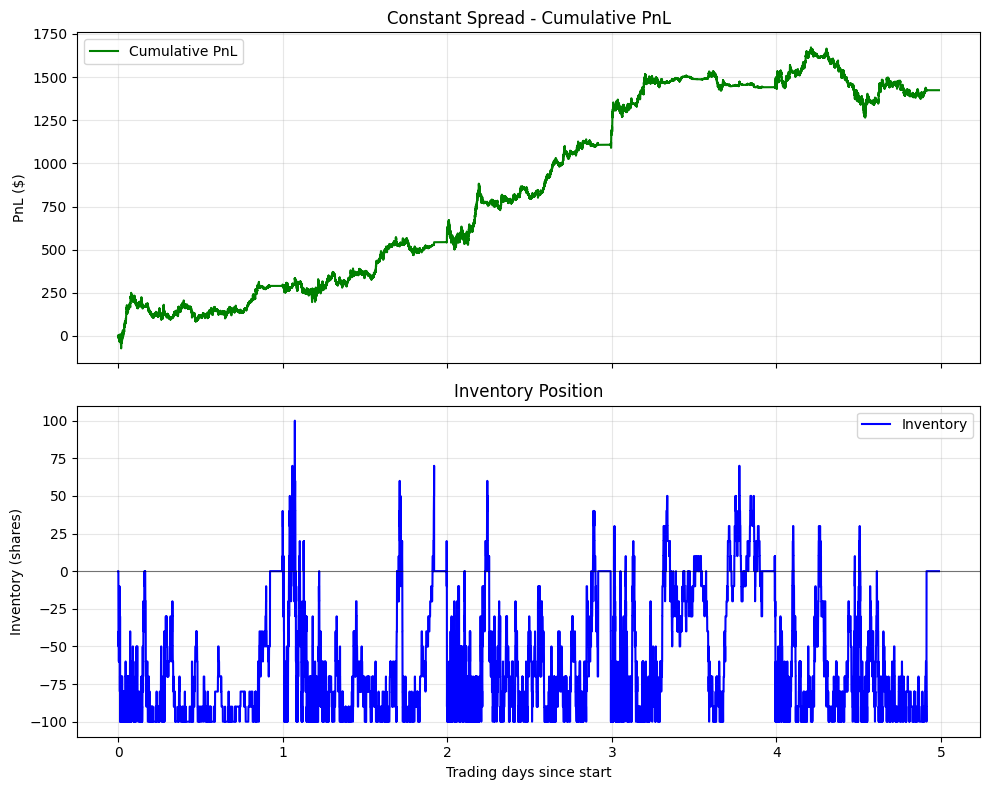

In [13]:
constant_quote_fn = constant_spread_strategy(
    constant=0.02,
    tick_size=STRATEGY_PARAMS["tick_size"],
    col_bid1="bid1",
    col_ask1="ask1",
)

results_constant, metrics_constant = run_backtest(
    df_1s=strategy_test,
    df_evt=df_evt_test,
    quote_fn=constant_quote_fn,
    cfg=bt_cfg,
    initial_cash=0.0,
    initial_inventory=0.0,
)

metrics_constant_series = pd.Series(metrics_constant, name="constant_spread").reindex(BACKTEST_METRICS)
display(metrics_constant_series.to_frame())

plot_results(results_constant, title="Constant Spread")


## Baseline Stoikov Backtest

,baseline_stoikov
pnl_final,1375.999689
pnl_std,1.147497
sharpe_1s,0.010272
avg_abs_inventory,45.643686
fill_rate,0.026179
volume,31360.000000


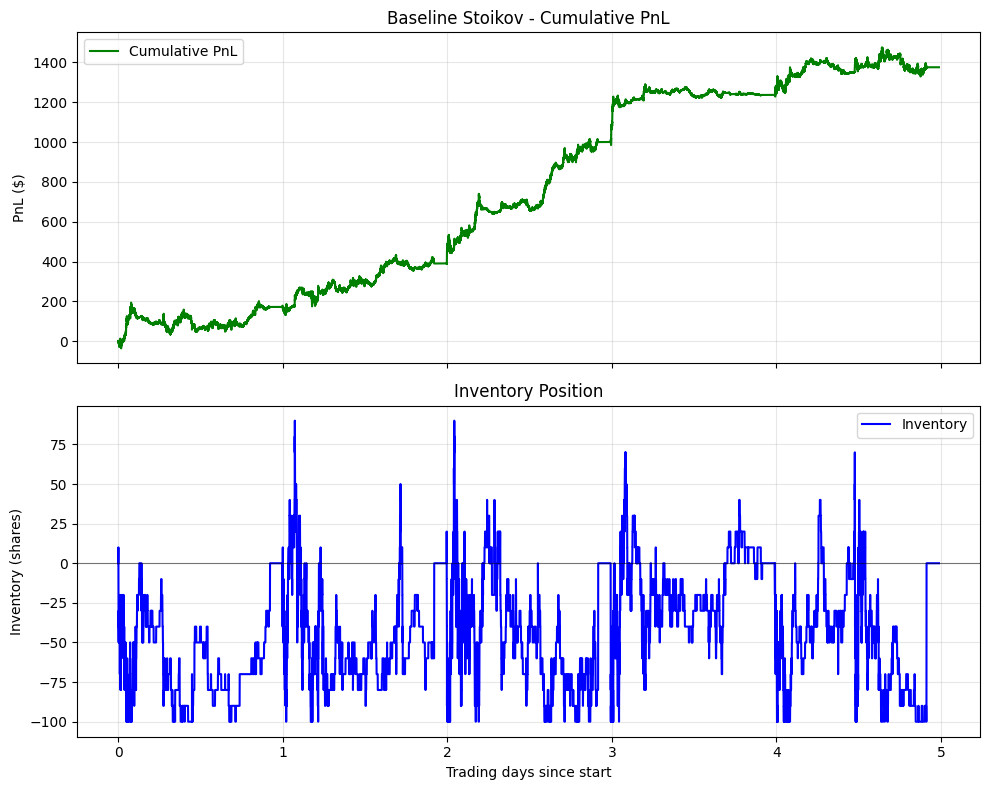

In [14]:
baseline_cfg = InventoryMMConfig(
    gamma=STRATEGY_PARAMS["gamma"],
    sigma=train_sigma_price_per_sqrt_second,
    k=STRATEGY_PARAMS["k"],
    T=STRATEGY_PARAMS["T"],
    q_max=STRATEGY_PARAMS["q_max"],
    col_mid="mid",
    col_time="time_abs_s",
)

baseline_quote_fn = stoikov_quote_fn(baseline_cfg)

results_baseline, metrics_baseline = run_backtest(
    df_1s=strategy_test,
    df_evt=df_evt_test,
    quote_fn=baseline_quote_fn,
    cfg=bt_cfg,
    initial_cash=0.0,
    initial_inventory=0.0,
)

metrics_baseline_series = pd.Series(metrics_baseline, name="baseline_stoikov").reindex(BACKTEST_METRICS)
display(metrics_baseline_series.to_frame())

plot_results(results_baseline, title="Baseline Stoikov")


## ML Stoikov Extension Backtest

,ml_extension
pnl_final,1312.300446
pnl_std,0.846451
sharpe_1s,0.013281
avg_abs_inventory,39.881697
fill_rate,0.028295
volume,34060.000000


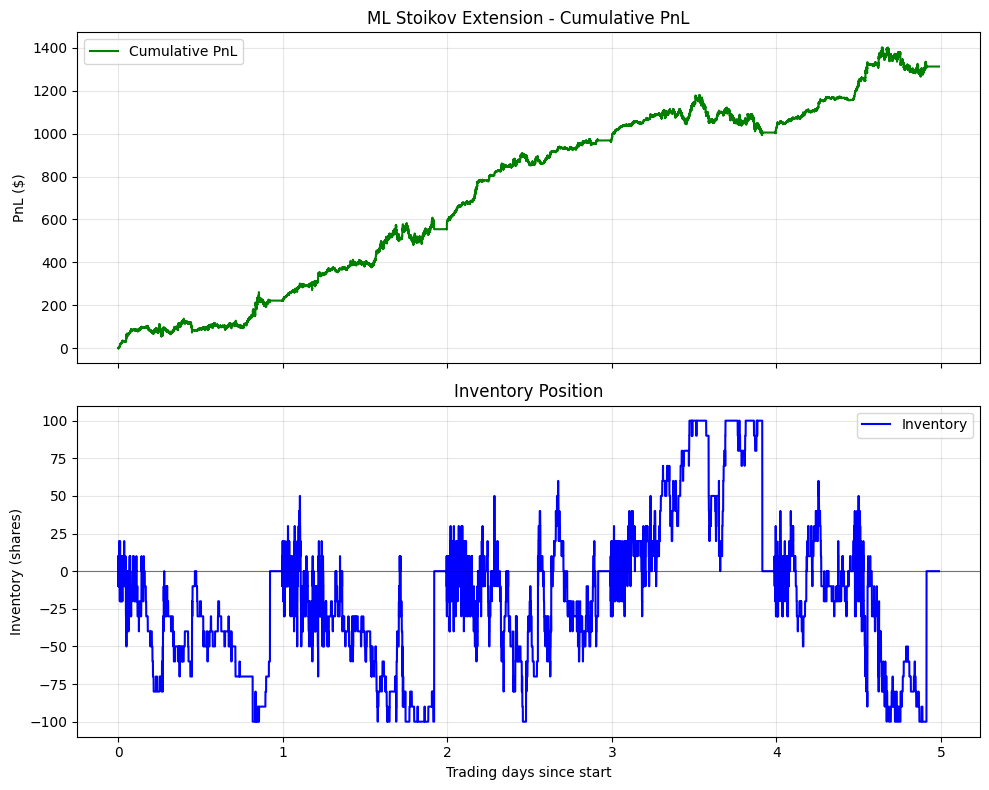

In [15]:
ext_cfg = StoikovExtensionConfig(
    gamma=STRATEGY_PARAMS["gamma"],
    k=STRATEGY_PARAMS["k"],
    T=STRATEGY_PARAMS["T"],
    sigma0=train_sigma_price_per_sqrt_second,
    alpha=STRATEGY_PARAMS["alpha"],
    q_max=STRATEGY_PARAMS["q_max"],
    skew_ticks=STRATEGY_PARAMS["skew_ticks"],
    col_mid="mid",
    col_time="time_abs_s",
    col_sigma="vol_pred_log_horizon",
    col_dir="dir_pred_signed",
    sigma_is_log=True,
    sigma_horizon=HORIZON,
)

ml_quote_fn = stoikov_extension_quote_fn(ext_cfg)

results_ml, metrics_ml = run_backtest(
    df_1s=strategy_test,
    df_evt=df_evt_test,
    quote_fn=ml_quote_fn,
    cfg=bt_cfg,
    initial_cash=0.0,
    initial_inventory=0.0,
)

metrics_ml_series = pd.Series(metrics_ml, name="ml_extension").reindex(BACKTEST_METRICS)
display(metrics_ml_series.to_frame())

plot_results(results_ml, title="ML Stoikov Extension")


## Oracle Stoikov Extension Backtest

,combined_oracle
pnl_final,2605.200385
pnl_std,0.657214
sharpe_1s,0.033958
avg_abs_inventory,28.483989
fill_rate,0.032793
volume,39220.000000


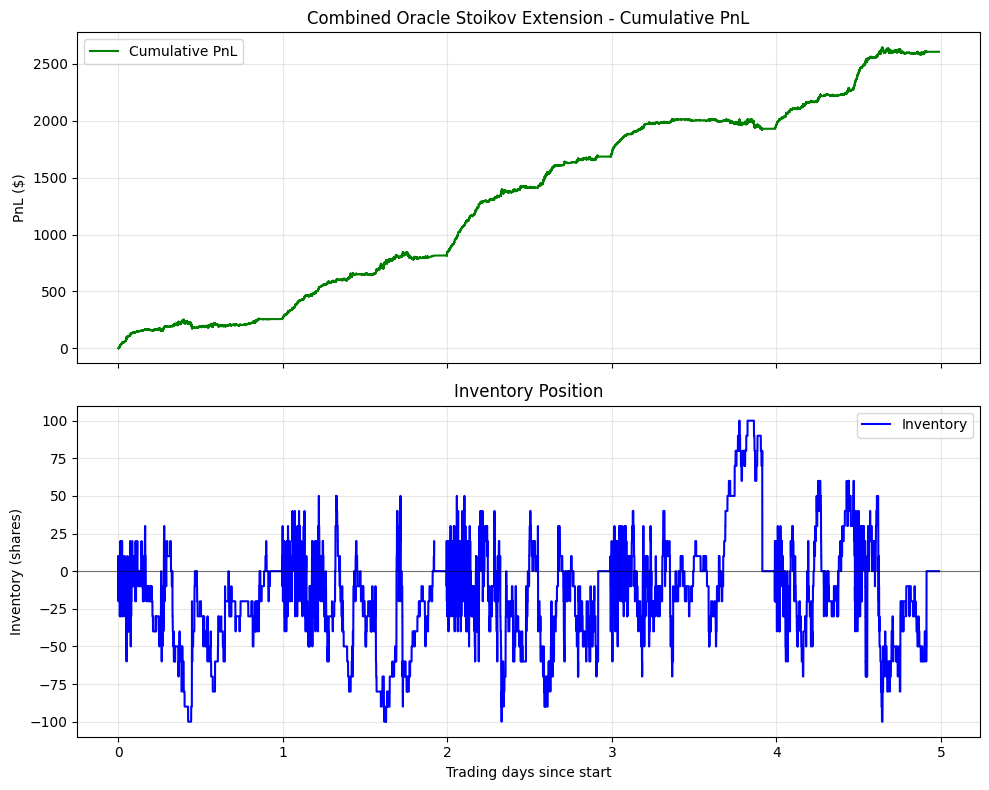

In [16]:
ORACLE_DIR_TO_SIGNED = {0: -1, 1: 1, 2: 0}

oracle_test = strategy_test.copy()
oracle_test["dir_oracle_signed"] = oracle_test["y_dir"].map(ORACLE_DIR_TO_SIGNED).astype(np.int8)
oracle_test["vol_oracle_log_horizon"] = oracle_test["y_vol"].astype(float).clip(lower=0.0).astype(np.float32)

oracle_cfg = StoikovExtensionConfig(
    gamma=STRATEGY_PARAMS["gamma"],
    k=STRATEGY_PARAMS["k"],
    T=STRATEGY_PARAMS["T"],
    sigma0=train_sigma_price_per_sqrt_second,
    alpha=STRATEGY_PARAMS["alpha"],
    q_max=STRATEGY_PARAMS["q_max"],
    skew_ticks=STRATEGY_PARAMS["skew_ticks"],
    col_mid="mid",
    col_time="time_abs_s",
    col_sigma="vol_oracle_log_horizon",
    col_dir="dir_oracle_signed",
    sigma_is_log=True,
    sigma_horizon=HORIZON,
)

oracle_quote_fn = stoikov_extension_quote_fn(oracle_cfg)

results_oracle, metrics_oracle = run_backtest(
    df_1s=oracle_test,
    df_evt=df_evt_test,
    quote_fn=oracle_quote_fn,
    cfg=bt_cfg,
    initial_cash=0.0,
    initial_inventory=0.0,
)

metrics_oracle_series = pd.Series(metrics_oracle, name="combined_oracle").reindex(BACKTEST_METRICS)
display(metrics_oracle_series.to_frame())

plot_results(results_oracle, title="Combined Oracle Stoikov Extension")



## Oracle Component Backtests


In [17]:
oracle_vol_test = strategy_test.copy()
oracle_vol_test["vol_oracle_log_horizon"] = oracle_vol_test["y_vol"].astype(float).clip(lower=0.0).astype(np.float32)
oracle_vol_test["dir_zero"] = np.int8(0)

oracle_vol_cfg = StoikovExtensionConfig(
    gamma=STRATEGY_PARAMS["gamma"],
    k=STRATEGY_PARAMS["k"],
    T=STRATEGY_PARAMS["T"],
    sigma0=train_sigma_price_per_sqrt_second,
    alpha=STRATEGY_PARAMS["alpha"],
    q_max=STRATEGY_PARAMS["q_max"],
    skew_ticks=STRATEGY_PARAMS["skew_ticks"],
    col_mid="mid",
    col_time="time_abs_s",
    col_sigma="vol_oracle_log_horizon",
    col_dir="dir_zero",
    sigma_is_log=True,
    sigma_horizon=HORIZON,
)

oracle_vol_quote_fn = stoikov_extension_quote_fn(oracle_vol_cfg)

results_oracle_vol, metrics_oracle_vol = run_backtest(
    df_1s=oracle_vol_test,
    df_evt=df_evt_test,
    quote_fn=oracle_vol_quote_fn,
    cfg=bt_cfg,
    initial_cash=0.0,
    initial_inventory=0.0,
)

metrics_oracle_vol_series = pd.Series(metrics_oracle_vol, name="volatility_oracle").reindex(BACKTEST_METRICS)

oracle_dir_test = strategy_test.copy()
oracle_dir_test["dir_oracle_signed"] = oracle_dir_test["y_dir"].map(ORACLE_DIR_TO_SIGNED).astype(np.int8)
oracle_dir_test["sigma_baseline_price_per_sqrt_second"] = np.float32(train_sigma_price_per_sqrt_second)

oracle_dir_cfg = StoikovExtensionConfig(
    gamma=STRATEGY_PARAMS["gamma"],
    k=STRATEGY_PARAMS["k"],
    T=STRATEGY_PARAMS["T"],
    sigma0=train_sigma_price_per_sqrt_second,
    alpha=STRATEGY_PARAMS["alpha"],
    q_max=STRATEGY_PARAMS["q_max"],
    skew_ticks=STRATEGY_PARAMS["skew_ticks"],
    col_mid="mid",
    col_time="time_abs_s",
    col_sigma="sigma_baseline_price_per_sqrt_second",
    col_dir="dir_oracle_signed",
    sigma_is_log=False,
    sigma_horizon=1,
)

oracle_dir_quote_fn = stoikov_extension_quote_fn(oracle_dir_cfg)

results_oracle_dir, metrics_oracle_dir = run_backtest(
    df_1s=oracle_dir_test,
    df_evt=df_evt_test,
    quote_fn=oracle_dir_quote_fn,
    cfg=bt_cfg,
    initial_cash=0.0,
    initial_inventory=0.0,
)

metrics_oracle_dir_series = pd.Series(metrics_oracle_dir, name="direction_oracle").reindex(BACKTEST_METRICS)

oracle_comparison = pd.concat(
    [metrics_oracle_vol_series, metrics_oracle_dir_series, metrics_oracle_series],
    axis=1,
).loc[BACKTEST_METRICS]

display(oracle_comparison)



,volatility_oracle,direction_oracle,combined_oracle
pnl_final,1269.599994,2834.300427,2605.200385
pnl_std,0.598172,1.169516,0.657214
sharpe_1s,0.018182,0.020761,0.033958
avg_abs_inventory,26.154248,47.139736,28.483989
fill_rate,0.029649,0.029117,0.032793
volume,35460.000000,34860.000000,39220.000000


## Head-To-Head Comparison

In [18]:
comparison = pd.concat(
    [
        metrics_constant_series,
        metrics_baseline_series,
        metrics_oracle_vol_series,
        metrics_oracle_dir_series,
        metrics_oracle_series,
        metrics_ml_series,
    ],
    axis=1,
).loc[BACKTEST_METRICS]

display(comparison)



,constant_spread,baseline_stoikov,volatility_oracle,direction_oracle,combined_oracle,ml_extension
pnl_final,1424.200043,1375.999689,1269.599994,2834.300427,2605.200385,1312.300446
pnl_std,1.564034,1.147497,0.598172,1.169516,0.657214,0.846451
sharpe_1s,0.007801,0.010272,0.018182,0.020761,0.033958,0.013281
avg_abs_inventory,63.487073,45.643686,26.154248,47.139736,28.483989,39.881697
fill_rate,0.052641,0.026179,0.029649,0.029117,0.032793,0.028295
volume,62840.000000,31360.000000,35460.000000,34860.000000,39220.000000,34060.000000


## Combined Strategy Diagnostics


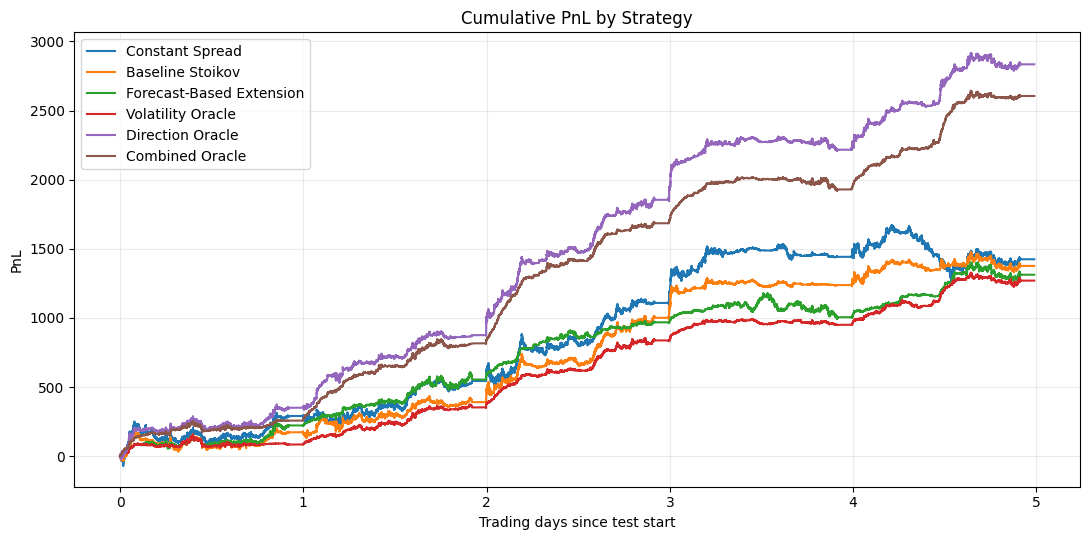

figures/combined_strategy_pnl.png


In [19]:
from pathlib import Path
import matplotlib.pyplot as plt

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def _first_existing_result(*names):
    for name in names:
        if name in globals():
            return globals()[name]
    return None


combined_results = [
    ("Constant Spread", _first_existing_result("results_constant")),
    ("Baseline Stoikov", _first_existing_result("results_baseline")),
    ("Forecast-Based Extension", _first_existing_result("results_ml")),
    ("Volatility Oracle", _first_existing_result("results_oracle_vol")),
    ("Direction Oracle", _first_existing_result("results_oracle_dir")),
    ("Combined Oracle", _first_existing_result("results_oracle")),
]
combined_results = [(name, df) for name, df in combined_results if df is not None and not df.empty]


def plot_combined_path(column, ylabel, title, output_name):
    fig, ax = plt.subplots(figsize=(11, 5.5))

    for name, df in combined_results:
        x = np.arange(len(df), dtype=float) / float(bt_cfg.session_seconds)
        ax.plot(x, df[column].to_numpy(dtype=float), linewidth=1.5, label=name)

    ax.set_title(title)
    ax.set_xlabel("Trading days since test start")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True)
    fig.tight_layout()

    output_path = FIGURE_DIR / output_name
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(output_path)


plot_combined_path(
    column="pnl",
    ylabel="PnL",
    title="Cumulative PnL by Strategy",
    output_name="combined_strategy_pnl.png",
)

